In [4]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.optim as optim
import math

# -----------------------------------
# settings
# -----------------------------------
dt = 0.01
eps = 0.01
Time_steps = 1500
iters = 300

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [6]:
class LorenzStep(nn.Module):
    def __init__(self, dt=0.01):
        super().__init__()
        self.sigma = 10.0
        self.rho = 28.0
        self.beta = 8.0 / 3.0
        self.dt = dt

    def forward(self, x):
        X = x[:, 0]
        Y = x[:, 1]
        Z = x[:, 2]

        dx = self.sigma * (Y - X)
        dy = X * (self.rho - Z) - Y
        dz = X * Y - self.beta * Z

        # Euler step
        X = X + self.dt * dx
        Y = Y + self.dt * dy
        Z = Z + self.dt * dz

        return torch.stack([X, Y, Z], dim=1)


model = LorenzStep(dt=dt).to(device)

In [7]:
def loss_fn(A,B):
  return torch.mean((A - B)**2)


Running NIO for T = 100
iter 0 loss -1.8486491441726685
iter 100 loss -3.8298168182373047
iter 200 loss -3.7576937675476074
T=100, avg x-separation=0.552852

Running NIO for T = 200
iter 0 loss -0.568678617477417
iter 100 loss -9.272109031677246
iter 200 loss -9.262182235717773
T=200, avg x-separation=0.679043

Running NIO for T = 300
iter 0 loss -0.43384286761283875
iter 100 loss -4.316683769226074
iter 200 loss -4.3369221687316895
T=300, avg x-separation=0.612158

Running NIO for T = 400
iter 0 loss -16.954498291015625
iter 100 loss -13.845276832580566
iter 200 loss -14.93990707397461
T=400, avg x-separation=1.656701

Running NIO for T = 500
iter 0 loss -26.166065216064453
iter 100 loss -55.41615295410156
iter 200 loss -63.70853042602539
T=500, avg x-separation=3.907234

Running NIO for T = 600
iter 0 loss -98.60902404785156
iter 100 loss -78.40216827392578
iter 200 loss -96.17677307128906
T=600, avg x-separation=6.780599

Running NIO for T = 700
iter 0 loss -120.52017211914062
iter

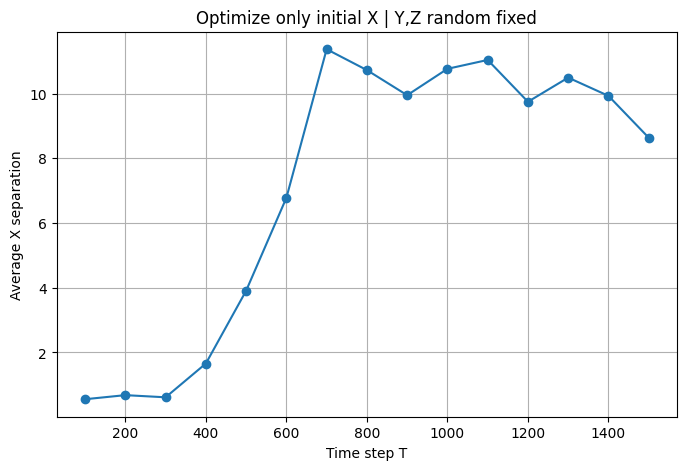

In [8]:
# bounds
low  = torch.tensor([-20.0, -30.0, 0.0], device=device)
high = torch.tensor([20.0, 30.0, 50.0], device=device)

N = 200      #### 200 random points
T_list = list(range(100, 1501, 100)) ## list of timestep 100 - 1500

avg_sep_list = []

for Time_steps in T_list:
    print(f"\nRunning NIO for T = {Time_steps}")

    x_param = torch.randn(N, 1, device=device, requires_grad=True)

    yz_fixed = torch.randn(N, 2, device=device)   # non learnable and fixed y and z

    optimizer = optim.Adam([x_param], lr=0.05)

    for i in range(iters):

        # x bounded
        x_val = low[0] + (high[0] - low[0]) * torch.sigmoid(x_param)

        # y,z bounded random fixed
        yz_val = low[1:] + (high[1:] - low[1:]) * torch.sigmoid(yz_fixed)

        # combine [x,y,z]
        x0 = torch.cat([x_val, yz_val], dim=1)

        xA = x0
        xB = x0 + eps

        for t in range(Time_steps):
            xA = model(xA)
            xB = model(xB)

        # optimize ONLY x-coordinate divergence
        #x_sep = xA[:, 0] - xB[:, 0]

        loss = -(loss_fn(xA,xB))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if i % 100 == 0:
            print("iter", i, "loss", loss.item())


    with torch.no_grad():

        x_val = low[0] + (high[0] - low[0]) * torch.sigmoid(x_param)
        yz_val = low[1:] + (high[1:] - low[1:]) * torch.sigmoid(yz_fixed)

        x0 = torch.cat([x_val, yz_val], dim=1)

        xA = x0
        xB = x0 + eps

        for t in range(Time_steps):
            xA = model(xA)
            xB = model(xB)

        final_sep = torch.abs(xA[:, 0] - xB[:, 0])

        avg_sep = final_sep.mean().item()
        avg_sep_list.append(avg_sep)

        print(f"T={Time_steps}, avg x-separation={avg_sep:.6f}")

# -----------------------------------
# plot
# -----------------------------------
plt.figure(figsize=(8,5))
plt.plot(T_list, avg_sep_list, marker='o')
plt.xlabel("Time step T")
plt.ylabel("Average X separation")
plt.title("Optimize only initial X | Y,Z random fixed")
plt.grid(True)
plt.show()

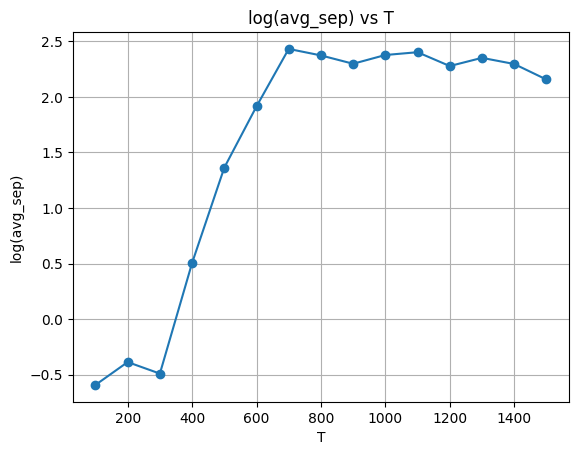

In [9]:
import numpy as np

#avg_sep_list
# taking the log of the lists
avg_sep_list_log = [np.log(x) for x in avg_sep_list ]
plot = plt.plot(T_list, avg_sep_list_log, marker='o')
plt.xlabel('T')
plt.ylabel('log(avg_sep)')
plt.title('log(avg_sep) vs T')
plt.grid(True)
plt.show()

In [10]:
############ calculate the theroritical value ####################
lam = 0.9
eps = 0.01
L = 20
dt = 0.01

# Compute Topt (in steps)
Topt = math.log(L / eps) / (lam * dt)
print(f"Topt = {Topt}")



Topt = 844.5447177268979


In [11]:
theory_sep = [
    eps * math.exp(lam * T * dt)
    for T in T_list
]


Text(0.5, 1.0, 'NIO vs Theory Separation')

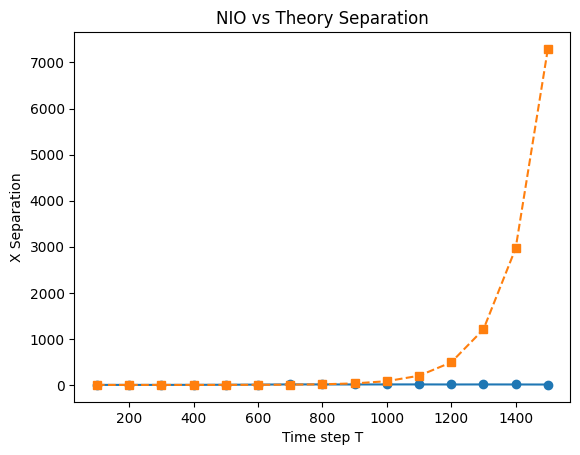

In [12]:
plot = plt.plot(T_list[:], avg_sep_list[:], marker='o', label="NIO Avg X Separation")
plot = plt.plot(T_list[:], theory_sep[:], marker='s',linestyle='--', label="Theory Separation " )
plt.xlabel("Time step T")
plt.ylabel("X Separation")
plt.title("NIO vs Theory Separation")

Text(0.5, 1.0, 'NIO vs Theory Separation')

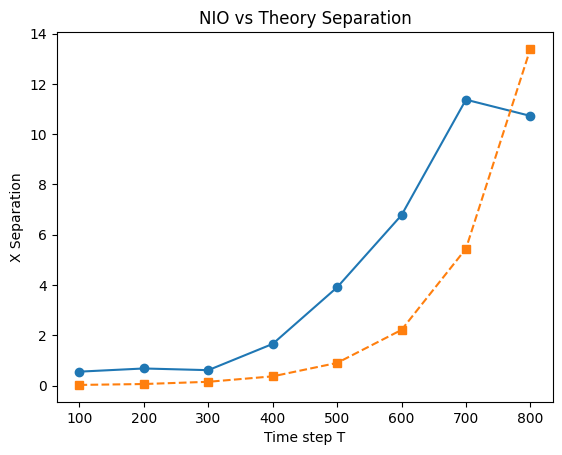

In [13]:
plot = plt.plot(T_list[:-7], avg_sep_list[:-7], marker='o', label="NIO Avg X Separation")
plot = plt.plot(T_list[:-7], theory_sep[:-7], marker='s',linestyle='--', label="Theory Separation " )
plt.xlabel("Time step T")
plt.ylabel("X Separation")
plt.title("NIO vs Theory Separation")